# 📍 Minería de Datos — KNN: K-Nearest Neighbors
## Clase comparación con Árboles de Decisión + taller final
- Juan Diego Grajales Castillo- 20221020128
- Julian David Celis Giraldo  - 20222020041
- Sara Nicolle Martinez Moreno- 20231020116
- David Santiago Aldana Gonzalez - 20222020158

---

## Propósito de la clase

En la clase anterior se estudió un modelo basado en reglas: **Árboles de Decisión**. En esta clase estudiaremos un modelo totalmente diferente: **KNN — K-Nearest Neighbors**.

La idea central de KNN es sencilla:

> Para clasificar un nuevo caso, busque los casos más parecidos en los datos históricos y tome una decisión por votación.

Usaremos nuevamente el dataset **Titanic** para mantener continuidad con la clase anterior.

---

## Resultados esperados de aprendizaje

Al finalizar la clase, el estudiante debe poder:

1. Explicar la intuición de KNN.
2. Entender el concepto de vecino más cercano.
3. Calcular e interpretar distancia euclidiana.
4. Explicar por qué KNN depende fuertemente de la escala.
5. Entrenar un clasificador KNN en Python.
6. Comparar KNN sin escalado y con escalado.
7. Evaluar KNN usando métricas de clasificación.
8. Analizar el efecto de elegir diferentes valores de \(k\).
9. Comparar KNN contra árbol de decisión.
10. Justificar qué modelo usaría según el contexto.

# 1. Ubicación dentro del curso

Hasta este punto se han trabajado conceptos generales de minería de datos, CRISP-DM, preparación de datos, train/test, métricas de clasificación, regresión logística y árboles de decisión.

Ahora seguimos consolidando clasificación supervisada con un modelo basado en distancia.

| Modelo | ¿Cómo toma decisiones? | Tipo de lógica |
|---|---|---|
| Regresión logística | Probabilidad mediante una función | Modelo paramétrico |
| Árbol de decisión | Reglas IF-THEN | Modelo basado en reglas |
| KNN | Vecinos más parecidos | Modelo basado en similitud |

La clase anterior el modelo preguntaba:

\`\`\`text
¿Sex <= 0.5?
¿Pclass <= 2?
¿Age <= 12?
\`\`\`

Hoy el modelo pregunta:

\`\`\`text
¿A qué pasajeros históricos se parece más este nuevo pasajero?
\`\`\`

# 2. Intuición de KNN

KNN significa **K-Nearest Neighbors**, o **K vecinos más cercanos**.

La lógica es:

1. Tengo un nuevo caso sin clasificar.
2. Calculo la distancia entre ese caso y todos los casos del entrenamiento.
3. Selecciono los \(k\) casos más cercanos.
4. Observo sus clases.
5. Asigno la clase más frecuente.

Ejemplo con \(k=5\):

\`\`\`text
Vecino 1 → sobrevivió
Vecino 2 → sobrevivió
Vecino 3 → no sobrevivió
Vecino 4 → sobrevivió
Vecino 5 → no sobrevivió
\`\`\`

Votación: sobrevivió 3 votos, no sobrevivió 2 votos. Predicción: sobrevivió.

KNN no construye reglas explícitas como un árbol. KNN guarda los datos y usa similitud al momento de predecir.

# 3. ¿KNN realmente “entrena”?

Técnicamente, KNN es un modelo de aprendizaje perezoso o **lazy learning**.

- Durante el entrenamiento, casi no aprende parámetros.
- Guarda los datos.
- El trabajo fuerte ocurre al momento de predecir.

| Modelo | Qué hace al entrenar | Qué hace al predecir |
|---|---|---|
| Árbol | Aprende reglas | Sigue las reglas |
| Regresión logística | Aprende coeficientes | Calcula probabilidad |
| KNN | Guarda datos | Busca vecinos y vota |

Implicaciones:

- Puede ser lento al predecir si hay muchos datos.
- Necesita una buena representación de las variables.
- Es muy sensible a la escala.

# 4. Distancia euclidiana

La distancia más común en KNN es la distancia euclidiana:

\[
d(x,z) = \sqrt{\sum_{j=1}^{p}(x_j - z_j)^2}
\]


Donde \(p\) es el número de variables. Si dos pasajeros tienen valores parecidos en las variables usadas, estarán cerca. Si son muy diferentes, estarán lejos.

En dos dimensiones:

\[
d(x,z) = \sqrt{(x_1-z_1)^2 + (x_2-z_2)^2}
\]

In [77]:
# ============================================================
# 1. Importar librerías
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# 5. Ejemplo manual de distancia

Supongamos dos pasajeros representados por edad y tarifa pagada.

Pasajero A: \(A = (22, 7.25)\)  
Pasajero B: \(B = (38, 71.28)\)

\[
d(A,B)=\sqrt{(22-38)^2 + (7.25-71.28)^2}
\]

In [78]:
pasajero_A = np.array([22, 7.25])
pasajero_B = np.array([38, 71.28])

distancia = np.sqrt(np.sum((pasajero_A - pasajero_B) ** 2))
print("Distancia entre A y B:", round(distancia, 2))

Distancia entre A y B: 66.0


## Discusión

La variable [96mFare[0m puede dominar la distancia porque sus valores pueden ser mucho más grandes que variables como [96mPclass[0m, [96mSibSp[0m o [96mParch[0m.

Esto nos lleva al punto más importante de KNN:

# KNN necesita escalado.

# 6. Problema de escala

KNN calcula distancias. Si una variable tiene valores grandes, puede dominar la distancia.

| Variable | Rango aproximado |
|---|---|
| Pclass | 1 a 3 |
| Sex | 0 a 1 |
| Age | 0 a 80 |
| Fare | 0 a 500 |

La variable [96mFare[0m puede pesar mucho más que [96mSex[0m o [96mPclass[0m. Esto no significa que sea más importante, sino que tiene una escala mayor.

## Solución: estandarización

\[
z = \frac{x - \mu}{\sigma}
\]

Después de estandarizar, cada variable tiene media aproximada 0 y desviación estándar aproximada 1.

# 7. Dataset Titanic

Usaremos el mismo dataset de la clase de árboles de decisión.

URL:

\`\`\`python
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
\`\`\`

El objetivo es predecir \(Survived\):

- 0: No sobrevivió.
- 1: Sobrevivió.

In [79]:
# ============================================================
# 2. Cargar dataset Titanic desde URL
# ============================================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)
df.head()

Dataset cargado correctamente.
Dimensiones: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 8. Comprensión inicial del dataset

Antes de modelar revisamos estructura, faltantes, distribución de la variable objetivo y seleccionamos variables para modelar.

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [81]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

faltantes

,faltantes,porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [82]:
conteo = df["Survived"].value_counts().sort_index()
porcentaje = df["Survived"].value_counts(normalize=True).sort_index() * 100

resumen_target = pd.DataFrame({
    "Survived": conteo.index,
    "descripcion": ["No sobrevivió", "Sobrevivió"],
    "conteo": conteo.values,
    "porcentaje": porcentaje.round(2).values
})

resumen_target

,Survived,descripcion,conteo,porcentaje
0,0,No sobrevivió,549,61.62
1,1,Sobrevivió,342,38.38


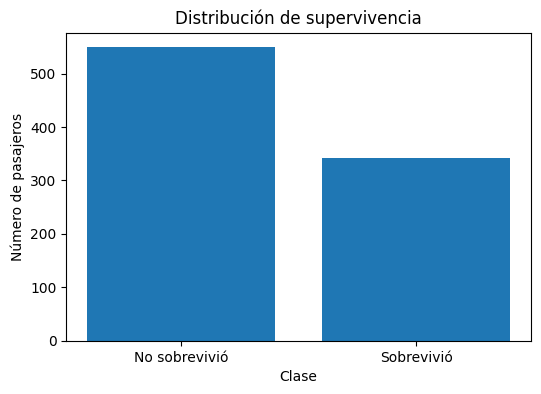

In [83]:
plt.figure(figsize=(6,4))
plt.bar(resumen_target["descripcion"], resumen_target["conteo"])
plt.title("Distribución de supervivencia")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.show()

# 9. Exploración rápida orientada a KNN

KNN usa distancias, entonces debemos mirar variables numéricas, rangos, escala y variables categóricas codificadas.

Usaremos variables simples:

| Variable | Tipo |
|---|---|
| Pclass | numérica ordinal |
| Sex | categórica transformada |
| Age | numérica |
| SibSp | numérica |
| Parch | numérica |
| Fare | numérica |
| Embarked | categórica transformada |

In [84]:
tabla_sex = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
tabla_sex.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]
tabla_sex.round(2)

,No sobrevivió (%),Sobrevivió (%)
Sex,,
female,25.80,74.20
male,81.11,18.89


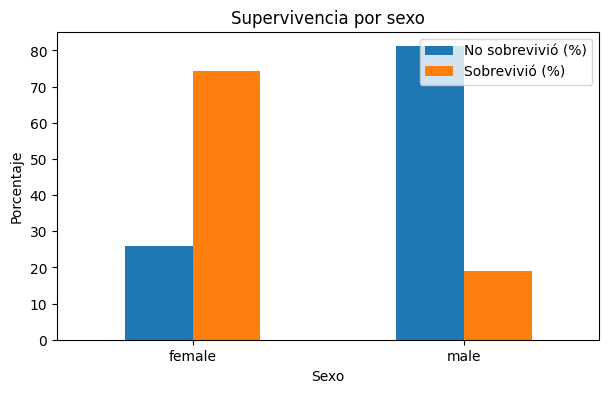

In [85]:
tabla_sex.plot(kind="bar", figsize=(7,4))
plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

In [86]:
tabla_clase = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
tabla_clase.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]
tabla_clase.round(2)

,No sobrevivió (%),Sobrevivió (%)
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


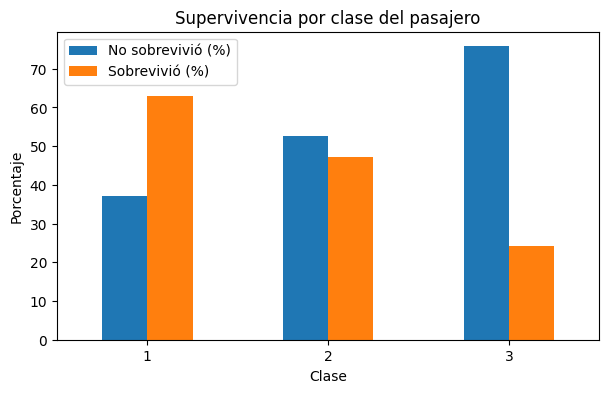

In [87]:
tabla_clase.plot(kind="bar", figsize=(7,4))
plt.title("Supervivencia por clase del pasajero")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

# 10. Preparación de datos

Para KNN debemos seleccionar variables útiles, manejar faltantes, convertir categóricas, separar X/y, separar train/test y escalar variables usando solo train.

## Cuidado con data leakage

El escalador debe aprender la media y desviación estándar usando solo entrenamiento. Por eso usaremos [96mPipeline[0m.

El pipeline garantiza:

1. Escala usando train.
2. Entrena KNN con train escalado.
3. Al predecir test, usa el escalado aprendido desde train.

In [88]:
df_model = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

# Imputación de valores faltantes
df_model["Age"] = df_model["Age"].fillna(df_model["Age"].median())
df_model["Embarked"] = df_model["Embarked"].fillna(df_model["Embarked"].mode()[0])

# Codificación de Sex
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

# One-hot encoding de Embarked
df_model = pd.get_dummies(df_model, columns=["Embarked"], drop_first=True)

print("Dimensiones del dataset modelado:", df_model.shape)
df_model.head()

Dimensiones del dataset modelado: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [89]:
df_model.isna().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [90]:
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

print("X:", X.shape)
print("y:", y.shape)
print("Variables predictoras:", list(X.columns))

X: (891, 8)
y: (891,)
Variables predictoras: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nDistribución train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nDistribución test:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (623, 8)
Test: (268, 8)

Distribución train:
Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64

Distribución test:
Survived
0    0.615672
1    0.384328
Name: proportion, dtype: float64


# 11. KNN sin escalado: demostración del problema

Primero entrenaremos KNN sin escalar. Esto no es lo recomendado, pero sirve para demostrar por qué la escala importa.

Usaremos \(k=5\). El parámetro \(k\) indica cuántos vecinos se usan para votar.

In [92]:
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5)
knn_sin_escalar.fit(X_train, y_train)
pred_sin_escalar = knn_sin_escalar.predict(X_test)

print("Resultados KNN sin escalado")
print(classification_report(y_test, pred_sin_escalar, target_names=["No sobrevivió", "Sobrevivió"]))

Resultados KNN sin escalado
               precision    recall  f1-score   support

No sobrevivió       0.73      0.78      0.75       165
   Sobrevivió       0.60      0.53      0.57       103

     accuracy                           0.69       268
    macro avg       0.67      0.66      0.66       268
 weighted avg       0.68      0.69      0.68       268



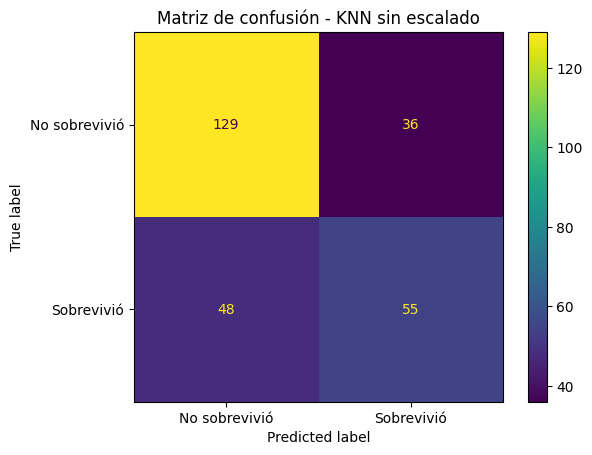

In [93]:
cm = confusion_matrix(y_test, pred_sin_escalar)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot()
plt.title("Matriz de confusión - KNN sin escalado")
plt.show()

## Discusión

Preguntas para estudiantes:

1. ¿Qué tan bueno parece el modelo?

Las métricas de evaluación obtenidas nos permite interpretar un bajo score, bajo recall, baja precisión y baja exactitud, en especial para nuestra variable objetivo sobrevivientes.

2. ¿Qué variables pueden estar dominando la distancia?

Variables como la edad y fare estan dominando la distancia, al no haber sido escaladas, ya sea por minmax y no fueron estandarizados, generando mayor dominancia en la distancia respecto a las otras variables que en su mayoria son meramente booleanas.

3. ¿Por qué [96mFare[0m puede afectar mucho?

Aumenta la distancia euclidiana entre punto aumentando el sesgo, mayor calculo y obteniendo un modelo menos eficiente y menos preciso, que no logra predecir de forma adecuada.

4. ¿Qué pasaría si agregáramos una variable como ingreso anual con valores en millones?

Las métricas del modelo se reducen en puntaje, dado que, una variable con valores tan grandes, genera mayor ruido, dado que se le asigna mayor peso a esta variable, generando imprecisiones en el modelo, por ende, es necesario normalizar y estandarizar las variables que nuestro modelo utilizará

Conclusión esperada: KNN no debe usarse sin revisar escalas.

# 12. KNN con escalado usando Pipeline

Ahora usaremos el enfoque correcto. El pipeline tendrá dos pasos:

1. [96mStandardScaler()[0m: estandariza variables.
2. [96mKNeighborsClassifier()[0m: entrena KNN.

Esto evita fuga de información porque el escalado se ajusta solo con train.

In [94]:
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipeline_knn.fit(X_train, y_train)
pred_knn = pipeline_knn.predict(X_test)

print("Resultados KNN con escalado")
print(classification_report(y_test, pred_knn, target_names=["No sobrevivió", "Sobrevivió"]))

Resultados KNN con escalado
               precision    recall  f1-score   support

No sobrevivió       0.81      0.86      0.84       165
   Sobrevivió       0.75      0.68      0.71       103

     accuracy                           0.79       268
    macro avg       0.78      0.77      0.77       268
 weighted avg       0.79      0.79      0.79       268



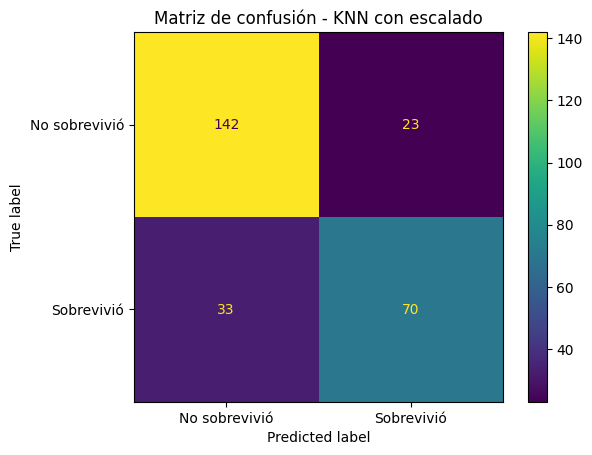

In [95]:
cm = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot()
plt.title("Matriz de confusión - KNN con escalado")
plt.show()

# 13. Comparación: KNN sin escalado vs KNN con escalado

Construiremos una tabla para comparar accuracy, precision, recall y F1-score.

In [96]:
def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall": recall_score(y_real, y_pred),
        "f1": f1_score(y_real, y_pred)
    }

comparacion_escalado = pd.DataFrame([
    evaluar_modelo("KNN sin escalado", y_test, pred_sin_escalar),
    evaluar_modelo("KNN con escalado", y_test, pred_knn)
])
comparacion_escalado

,modelo,accuracy,precision,recall,f1
0,KNN sin escalado,0.686567,0.604396,0.533981,0.567010
1,KNN con escalado,0.791045,0.752688,0.679612,0.714286


## Interpretación esperada

- KNN depende de distancias.
- Las distancias dependen de la escala.
- Por eso el escalado no es un detalle técnico menor: es parte del modelo.

> En KNN, preprocesar bien no es opcional; es parte de la definición del modelo.

# 14. ¿Cómo elegir \(k\)?

El parámetro \(k\) define cuántos vecinos votan.

## Si k es muy pequeño

- El modelo es sensible al ruido.
- Puede sobreajustar.
- Las fronteras de decisión son irregulares.

## Si k es muy grande

- El modelo se vuelve demasiado general.
- Puede subajustar.
- Puede favorecer la clase mayoritaria.

| k | Comportamiento |
|---|---|
| k = 1 | Muy flexible, sensible al ruido |
| k = 3 o 5 | Balance inicial frecuente |
| k grande | Más estable, pero puede perder detalle |

# 15. Evaluación de diferentes valores de k

Entrenaremos KNN con distintos valores de \(k\) y compararemos resultados. Usaremos pipeline para escalar siempre correctamente.

In [97]:
valores_k = list(range(1, 31))
resultados_k = []

for k in valores_k:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    resultados_k.append({
        "k": k,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test),
        "recall_test": recall_score(y_test, pred_test),
        "precision_test": precision_score(y_test, pred_test)
    })

df_k = pd.DataFrame(resultados_k)
df_k.head()

,k,accuracy_train,accuracy_test,f1_test,recall_test,precision_test
0,1,0.977528,0.787313,0.721951,0.718447,0.725490
1,2,0.884430,0.779851,0.662857,0.563107,0.805556
2,3,0.876404,0.809701,0.746269,0.728155,0.765306
3,4,0.849117,0.794776,0.692737,0.601942,0.815789
4,5,0.860353,0.791045,0.714286,0.679612,0.752688


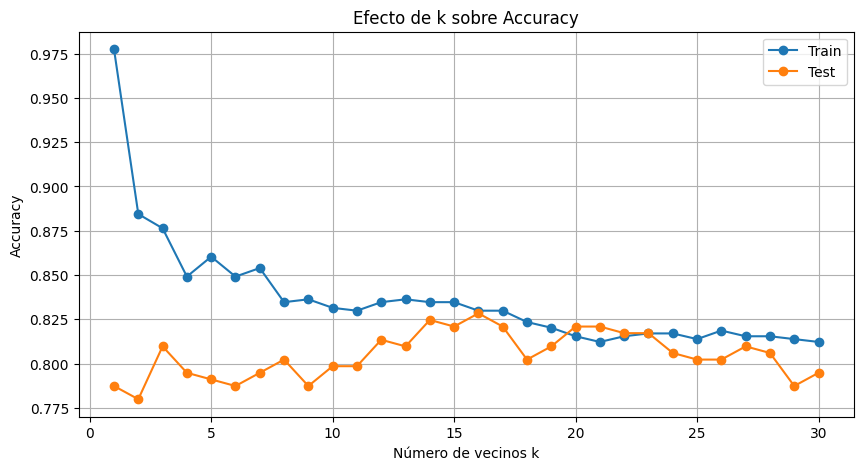

In [98]:
plt.figure(figsize=(10,5))
plt.plot(df_k["k"], df_k["accuracy_train"], marker="o", label="Train")
plt.plot(df_k["k"], df_k["accuracy_test"], marker="o", label="Test")
plt.title("Efecto de k sobre Accuracy")
plt.xlabel("Número de vecinos k")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

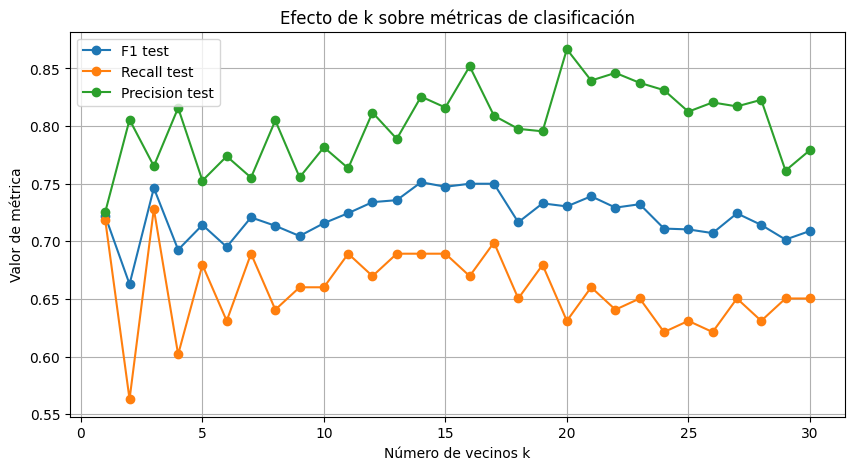

In [99]:
plt.figure(figsize=(10,5))
plt.plot(df_k["k"], df_k["f1_test"], marker="o", label="F1 test")
plt.plot(df_k["k"], df_k["recall_test"], marker="o", label="Recall test")
plt.plot(df_k["k"], df_k["precision_test"], marker="o", label="Precision test")
plt.title("Efecto de k sobre métricas de clasificación")
plt.xlabel("Número de vecinos k")
plt.ylabel("Valor de métrica")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
df_k.sort_values("f1_test", ascending=False).head(10)

,k,accuracy_train,accuracy_test,f1_test,recall_test,precision_test
13,14,0.834671,0.824627,0.751323,0.689320,0.825581
15,16,0.829856,0.828358,0.750000,0.669903,0.851852
16,17,0.829856,0.820896,0.750000,0.699029,0.808989
14,15,0.834671,0.820896,0.747368,0.689320,0.816092
2,3,0.876404,0.809701,0.746269,0.728155,0.765306
20,21,0.812199,0.820896,0.739130,0.660194,0.839506
12,13,0.836276,0.809701,0.735751,0.689320,0.788889
11,12,0.834671,0.813433,0.734043,0.669903,0.811765
18,19,0.820225,0.809701,0.732984,0.679612,0.795455
22,23,0.817014,0.817164,0.732240,0.650485,0.837500


## Interpretación

Preguntas para clase:

1. ¿Qué valor de k da mejor F1?

Un k de 14, nos provee el mejor F1-score

2. ¿Qué pasa con k = 1?

Obtenemos un valor muy similar entre las diferentes métricas, pero para nuestro ejercicio, especificamente buscamos aumentar el F1-score, dado que buscamos el equilibrio entre recall y precision, en este caso, nos importan ambos, tanto los falsos positivos, como los falsos negativos, asi mismo, nuestra precisión para los datos de entrenamiento, es muy alta, pero para nuestros datos de prueba, es muy baja, siendo desbalanceado.

1. ¿Qué pasa cuando k crece mucho?

Aumenta el sesgo, al tomar mayor cantidad de vecinos cercanos, disminuyendo las métricas, empeorando la calidadd de nuestro modelo.

4. ¿Hay diferencia entre accuracy y F1?

Accuracy mide el total de aciertos y F1-score, nos da un puntaje que relaciona recall y precisión, que busca el equilibro, penalizando ambas métricas.

5. ¿Elegiría k solo por la métrica o también por estabilidad?

Elegimos k considerando el desempeño (F1, acuraccy, etc.) y la estabilidad entre particiones, un buen k, nos permite mantener resultados consistentes

En proyectos reales se usa validación cruzada. En esta clase usamos train/test para mantener el foco conceptual.

# 16. Entrenar KNN final con el mejor k observado

Seleccionaremos el mejor k según F1-score en test para efectos pedagógicos. En un proyecto real, este ajuste debería hacerse con validación cruzada sobre entrenamiento, no usando test repetidamente.

In [101]:
mejor_k = int(df_k.sort_values("f1_test", ascending=False).iloc[0]["k"])
print("Mejor k observado según F1 test:", mejor_k)

knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k))
])

knn_final.fit(X_train, y_train)
pred_knn_final = knn_final.predict(X_test)

print(classification_report(y_test, pred_knn_final, target_names=["No sobrevivió", "Sobrevivió"]))

Mejor k observado según F1 test: 14
               precision    recall  f1-score   support

No sobrevivió       0.82      0.91      0.86       165
   Sobrevivió       0.83      0.69      0.75       103

     accuracy                           0.82       268
    macro avg       0.82      0.80      0.81       268
 weighted avg       0.82      0.82      0.82       268



# 17. Comparación contra Árbol de Decisión

Ahora compararemos KNN con el árbol visto en la clase anterior.

| Modelo | Lógica |
|---|---|
| Árbol | Reglas |
| KNN | Similitud |

In [102]:
arbol = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
arbol.fit(X_train, y_train)
pred_arbol = arbol.predict(X_test)

comparacion_modelos = pd.DataFrame([
    evaluar_modelo("Árbol de decisión", y_test, pred_arbol),
    evaluar_modelo(f"KNN final k={mejor_k}", y_test, pred_knn_final)
])
comparacion_modelos

,modelo,accuracy,precision,recall,f1
0,Árbol de decisión,0.794776,0.875000,0.543689,0.670659
1,KNN final k=14,0.824627,0.825581,0.689320,0.751323


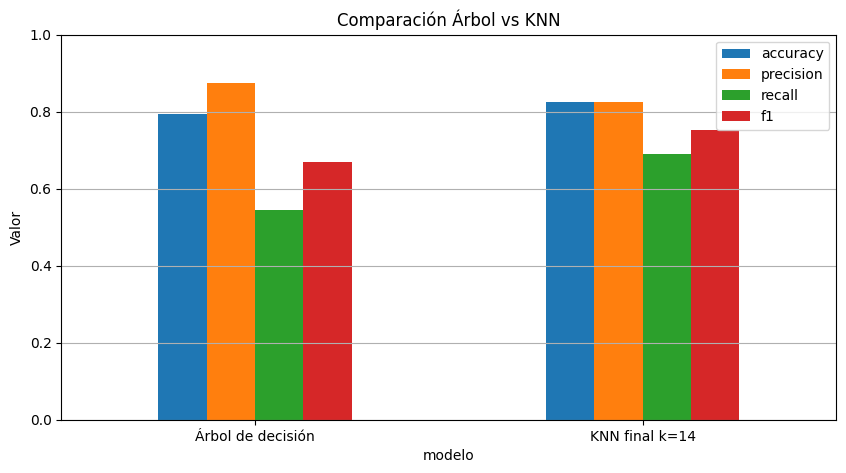

In [103]:
metricas = ["accuracy", "precision", "recall", "f1"]
comparacion_modelos.set_index("modelo")[metricas].plot(kind="bar", figsize=(10,5))
plt.title("Comparación Árbol vs KNN")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

## Discusión comparativa

1. ¿Cuál modelo tiene mejor accuracy?

KNN tiene mejor accuracy, por lo que es un modelo más preciso globalmente.

2. ¿Cuál tiene mejor recall?

KNN supera al árbol en recall, lo que significa que detecta más casos positivos reales.

3. ¿Cuál tiene mejor F1?

KNN mejora el F1-score, siendo esta métrica prevalente para búsqueda de balance.

4. ¿Cuál es más interpretable?

El árbol de decisión es más interpretable, ya que al tener reglas condicionales, permiten interpretar los parámetros de clasificación, en comparación con KNN.

5. ¿Cuál depende más del preprocesamiento?

KNN depende más del preprocesamiento, datos no estandarizados pueden generar sesgo.

6. ¿Cuál sería más fácil de explicar a un usuario no técnico?

Árbol de decisión es explícito, permitiendo explicar a un usuario no técnico su funcionamiento.

7. ¿Cuál podría escalar peor con muchísimos datos?

KNN podría escalar peor con mayor cantidad de variables y datos.

Lectura esperada: el árbol es más interpretable; KNN depende mucho del escalado; no existe un único mejor modelo, depende del objetivo.

# 18. Visualización sencilla en 2D

Para entender KNN de manera visual, usaremos solo dos variables: Age y Fare. Esto no será el mejor modelo, pero sirve para visualizar cómo KNN piensa en términos de cercanía.

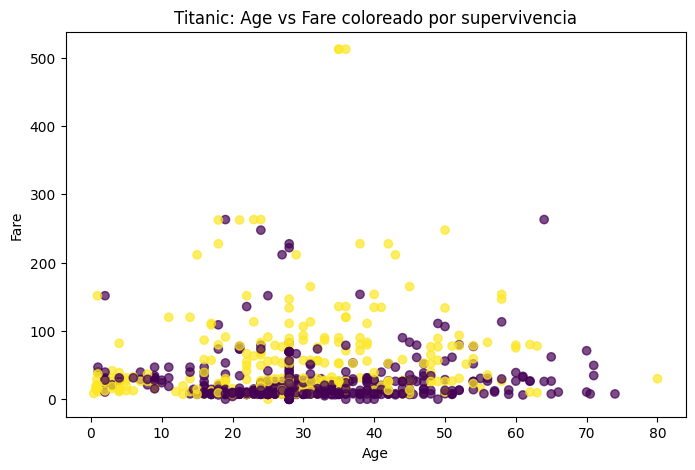

In [104]:
X_2d = df_model[["Age", "Fare"]]
y_2d = df_model["Survived"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.30, random_state=42, stratify=y_2d
)

knn_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_2d.fit(X2_train, y2_train)

plt.figure(figsize=(8,5))
plt.scatter(X_2d["Age"], X_2d["Fare"], c=y_2d, alpha=0.7)
plt.title("Titanic: Age vs Fare coloreado por supervivencia")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## Interpretación

Cada punto es un pasajero. KNN clasifica un nuevo punto mirando qué puntos cercanos tiene alrededor. Con solo dos variables se pierde información, así que este gráfico es pedagógico, no necesariamente el mejor modelo.

# 19. Ventajas y desventajas de KNN

## Ventajas

- Intuitivo.
- Fácil de implementar.
- No asume una forma funcional específica.
- Puede capturar fronteras de decisión no lineales.
- Útil como modelo base.

## Desventajas

- Muy sensible a la escala.
- Puede ser costoso al predecir con muchos datos.
- Se afecta por variables irrelevantes.
- Se afecta por datos ruidosos.
- No genera reglas tan claras como un árbol.
- Elegir k requiere experimentación.

## Recomendación práctica

KNN se debe usar con buen preprocesamiento, escalado, revisión de variables, comparación contra otros modelos y validación adecuada.

# 20. Errores comunes al usar KNN

| Error | Consecuencia |
|---|---|
| No escalar variables | Distancias sesgadas |
| Usar variables irrelevantes | Vecinos mal definidos |
| Elegir k sin evaluar | Modelo inestable |
| Evaluar solo con accuracy | Interpretación incompleta |
| No separar train/test | Evaluación engañosa |
| Escalar antes del split | Data leakage |

> En KNN, la calidad de la distancia define la calidad del modelo.

# 🧪 21. Taller final de clase

## Objetivo

Entrenar, evaluar y comparar un modelo KNN usando sus datos.

## Entregable

Un notebook o documento con:

1. Preparación de datos.
2. KNN sin escalado.
3. KNN con escalado.
4. Comparación de valores de k.
5. Comparación contra árbol de decisión.
6. Matriz de confusión.
7. Conclusión profesional.

No se evalúa solo que el código funcione. Se evalúa principalmente la interpretación.

## Parte A — Comprensión conceptual

Responda:

1. ¿Qué significa KNN?
    K-Nearest Neighbors, guarda todos los datos de entrenamiento y cuando llega un nuevo dato de prueba busca los k puntos más cercanos, a través de la distancia euclidiana.

2. ¿Cómo clasifica KNN un nuevo registro?
    De acuerdo a los puntos más cercanos, si los puntos más cercanos de los datos entrenados pertenecen a una categoria, de acuerdo a la frecuencia de que ese nuevo registro pertenezca a esa misma clase aumenta

3. ¿Qué representa el parámetro \(k\)?
    Representa la cantidad de vecinos que evaluamos cercanos (distancia euclidiana, Manhattan, Minkowski) a ese nuevo dato que se ingresa evalua esos k vecinos cercanos y se determina la naturaleza de ese dato.

4. ¿Por qué KNN depende de la distancia?
    Porqué de acuerdo a la distancia determina la similitud entre puntos cercanos a un punto y la clasificación depende directamente de esos vecinos cercanos.

5. ¿Por qué el escalado es obligatorio o muy recomendable?
    Porqué en el caso de nuestro algoritmo KNN, al tomar variables con datos númericos muy grandes, la distancia entre puntos aumenta, generando sesgo y dando mayor peso a dichas variables númericas con mayor valor númerico

6. ¿Qué diferencia conceptual hay entre KNN y árbol de decisión?
   KNN es un algoritmo de machine learning que permite regresión y clasificación basado en distancia euclidiana entre puntos, ya sea clasificando por mayoria de clases o regresión por promedio de valores, mientras que un arbol de decisión tiene reglas claras que clasifican de acuerdo a esas reglas y niveles de profundidad definidos

## Parte B — Preparación de datos

Usamos las 20 variables de nuestro conjunto de datos job search platform efficacy, analizando nulos, pasos condicionales y su estructura

El primer paso es cargar nuestro conjunto de datos, analizar registros nulos, excluir variables que son nulas porqué no recibio oferta.

Enviamos nuestras variables del modelo a otro dataframe par no afectar los datos originales al transformarlos

### Imputación de datos
Imputamos datos a traves de su moda o mediana, según la variable, en nuestro caso, ya se habia realizado, por ende,no imputamos ningun dato, las variables categoricas, se utilizará one-hot encoding

Eliminamos registros que no recibieron ni aceptaron la oferta, teniendo alrededor de 35.000 datos, dividimos en un 70 | 30 nuestros datos para entrenamiento y prueba respectivamente.

Tras el hot-encoding transformamos las variables categóricas, por ende, finalizamos con 22 variables.

In [105]:
# ============================================================
# FUNCIÓN REUTILIZABLE: Preparar datos para clasificación
# ============================================================
def preparar_datos_clasificacion(archivo, variable_objetivo, variables_modelo, test_size=0.30, random_state=42):
    """
    Prepara datos para clasificación: carga, limpia, codifica y divide.

    Parámetros:
    - archivo: ruta del CSV
    - variable_objetivo: nombre de la columna a predecir
    - variables_modelo: lista de variables a usar
    - test_size: proporción de test (default: 0.30)
    - random_state: semilla aleatoria (default: 42)

    Retorna: X_train, X_test, y_train, y_test
    """
    df = pd.read_csv(archivo)
    df = df[variables_modelo].dropna(subset=[variable_objetivo])

    # Imputar variables numéricas con mediana
    vars_numericas = ["GPA", "Prior_Internships", "Extra_Curricular_Activities",
                      "Networking_Events_Attended", "Months_Searching", "Applications_Submitted",
                      "First_Round_Interviews", "Second_Round_Interviews", "Offer_Received"]
    for col in vars_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Imputar variables categóricas con moda
    vars_categoricas = ["University_Rating", "School_Size", "Region", "Major_Category", "Primary_Search_Platform"]
    for col in vars_categoricas:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # One-hot encoding
    df = pd.get_dummies(df, columns=vars_categoricas, drop_first=True)

    # Validar que no haya faltantes después de imputación
    if df.isna().sum().sum() > 0:
        print("⚠️ Aún hay valores faltantes después de imputación:")
        print(df.isna().sum()[df.isna().sum() > 0])
    else:
        print("✓ Validación: No hay valores faltantes")

    # Separar X e y
    X = df.drop(columns=[variable_objetivo])
    y = df[variable_objetivo]

    # Split con stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    return X_train, X_test, y_train, y_test


# PARTE B: Preparación de datos - Predicción Accepted_Offer

Cargamos el dataset y aplicamos la función de preparación para predecir si un candidato aceptará la oferta.


In [118]:
print("="*60)
print("PARTE B: Preparación de datos - Predicción Accepted_Offer")
print("="*60)

df_original = pd.read_csv("job_search_platform_efficacy_100k.csv")
print(f"\n📊 Dataset original: {df_original.shape} registros")
print(f"Valores nulos en Time_to_Offer_Days: {df_original['Time_to_Offer_Days'].isna().sum()}")
print(f"Estos son registros que NO recibieron oferta\n")

# Seleccionar variables comunes (sin variable objetivo)
variables_comunes = [
    "GPA", "Prior_Internships", "Extra_Curricular_Activities",
    "Networking_Events_Attended", "Months_Searching", "Applications_Submitted",
    "First_Round_Interviews", "Second_Round_Interviews", "Offer_Received",
    "University_Rating", "School_Size", "Region", "Major_Category", "Primary_Search_Platform"
]

# Usar función reutilizable para predecir Accepted_Offer
variables_modelo = ["Accepted_Offer"] + variables_comunes
X_train_t, X_test_t, y_train_t, y_test_t = preparar_datos_clasificacion(
    "job_search_platform_efficacy_100k.csv",
    "Accepted_Offer",
    variables_modelo
)

print(f"\n✅ Dataset preparado para Accepted_Offer:")
print(f"X_train: {X_train_t.shape}, X_test: {X_test_t.shape}")
print(f"Total variables: {X_train_t.shape[1]}")
print(f"Variables: {list(X_train_t.columns)}")


PARTE B: Preparación de datos - Predicción Accepted_Offer


FileNotFoundError: [Errno 2] No such file or directory: 'job_search_platform_efficacy_100k.csv'

## Parte C — Predicción de Offer_Received con selección de características

Se preparan datos para predecir Offer_Received reutilizando la función y variables comunes de Parte B.

In [ ]:
# Preparar datos para predecir Offer_Received
# Excluir Offer_Received de variables_comunes para evitar duplicados
variables_c = ["Offer_Received"] + [v for v in variables_comunes if v != "Offer_Received"]
X_train_c, X_test_c, y_train_c, y_test_c = preparar_datos_clasificacion(
    "job_search_platform_efficacy_100k.csv",
    "Offer_Received",
    variables_c
)

print(f"\n✅ Dataset preparado para Offer_Received:")
print(f"X_train: {X_train_c.shape}, X_test: {X_test_c.shape}")
print(f"Total variables: {X_train_c.shape[1]}")

✓ Validación: No hay valores faltantes

✅ Dataset preparado para Offer_Received:
X_train: (70000, 21), X_test: (30000, 21)
Total variables: 21


### C1. Preparación de datos y caracterización de variables

Realizaremos una validación, seleccionaremos las mejores variables para nuestro modelo KNN y compararemos basado en:

* Todas las variables sin escalar
* Top 10 variables sin escalar
* Todas las variables escaladas
* Top 10 variables escaladas

El top 10 de variables se realiza con SelectKBest, asigna un puntaje a cada variable según su influencia en la predicción para KNN


✓ Validación pre-selección:
  X_train faltantes: 0
  X_test faltantes: 0
  y_train faltantes: 0
  y_test faltantes: 0

✓ Reducción: 21 → 10 variables (-52%)
X_train_best: (70000, 10), X_test_best: (30000, 10)
Faltantes en X_best: 0



/tmp/ipykernel_18521/178706436.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


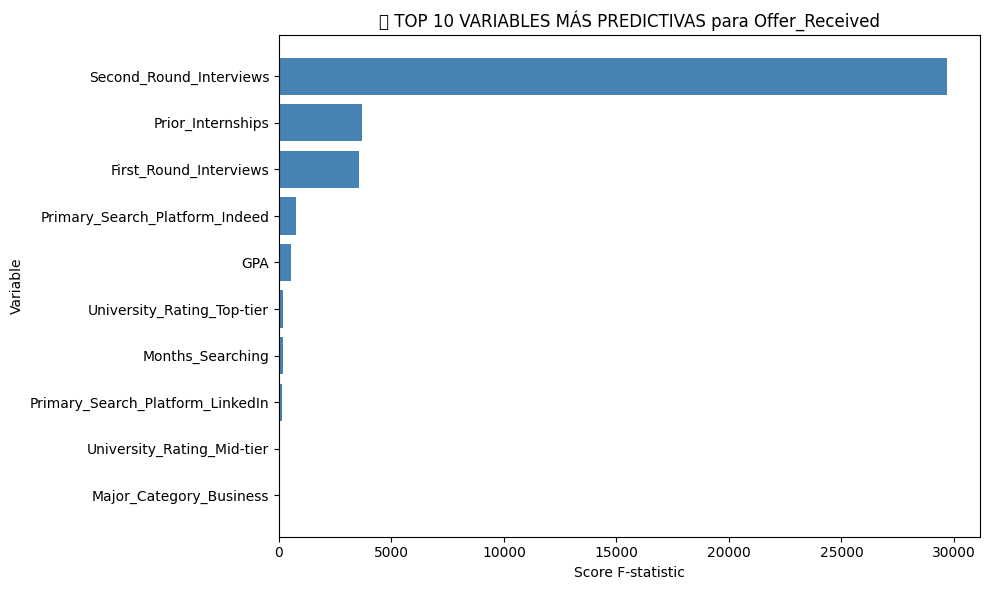

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Validar que no haya faltantes antes de la selección
print("✓ Validación pre-selección:")
print(f"  X_train faltantes: {X_train_c.isna().sum().sum()}")
print(f"  X_test faltantes: {X_test_c.isna().sum().sum()}")
print(f"  y_train faltantes: {y_train_c.isna().sum()}")
print(f"  y_test faltantes: {y_test_c.isna().sum()}\n")

# Seleccionar TOP 10 variables
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_c, y_train_c)

columnas_seleccionadas = X_train_c.columns[selector.get_support()].tolist()
importancia_vars = pd.DataFrame({
    "Variable": X_train_c.columns,
    "Score": selector.scores_
}).sort_values("Score", ascending=False)

X_train_c_best = X_train_c[columnas_seleccionadas]
X_test_c_best = X_test_c[columnas_seleccionadas]

print(f"✓ Reducción: {X_train_c.shape[1]} → {len(columnas_seleccionadas)} variables (-{(1-len(columnas_seleccionadas)/X_train_c.shape[1])*100:.0f}%)")
print(f"X_train_best: {X_train_c_best.shape}, X_test_best: {X_test_c_best.shape}")
print(f"Faltantes en X_best: {X_train_c_best.isna().sum().sum() + X_test_c_best.isna().sum().sum()}\n")

# Gráfica de TOP 10 variables
plt.figure(figsize=(10, 6))
top10_vars = importancia_vars.head(10).sort_values("Score")
plt.barh(top10_vars["Variable"], top10_vars["Score"], color="steelblue")
plt.xlabel("Score F-statistic")
plt.ylabel("Variable")
plt.title("📊 TOP 10 VARIABLES MÁS PREDICTIVAS para Offer_Received")
plt.tight_layout()
plt.show()

Las variables de mayor predicción en nuestro problema de predicción de oferta recibida, depende de si el candidato pasó a segunda ronda, las pasantias previas realizadas y su plataforma primaria de busqueda.

### C2. Análisis sin escalado: Todas vs Top 10 variables

En este apartado, tenemos el análisis de todas las variables vs Top 10 variables, sin escalar, comparando los resultados de las métricas.

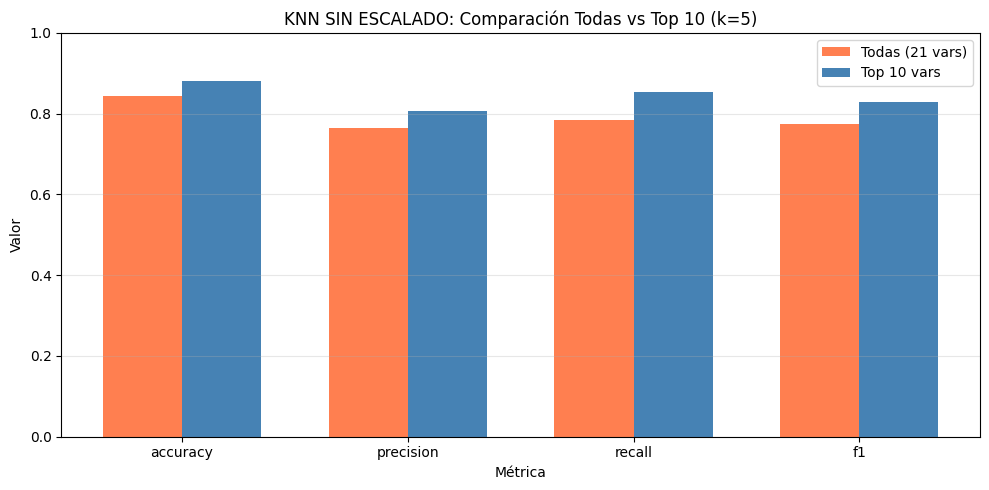

In [ ]:
# KNN SIN ESCALADO: Todas vs Top 10
knn_todas_sin = KNeighborsClassifier(n_neighbors=5)
knn_todas_sin.fit(X_train_c, y_train_c)
pred_todas_sin = knn_todas_sin.predict(X_test_c)

knn_best_sin = KNeighborsClassifier(n_neighbors=5)
knn_best_sin.fit(X_train_c_best, y_train_c)
pred_best_sin = knn_best_sin.predict(X_test_c_best)

comp_sin = pd.DataFrame([
    evaluar_modelo("Todas (21 vars)", y_test_c, pred_todas_sin),
    evaluar_modelo("Top 10 vars", y_test_c, pred_best_sin)
])

# Gráfica de comparación SIN ESCALADO
metricas = ["accuracy", "precision", "recall", "f1"]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas))
width = 0.35
ax.bar(x - width/2, comp_sin.iloc[0][metricas], width, label="Todas (21 vars)", color="coral")
ax.bar(x + width/2, comp_sin.iloc[1][metricas], width, label="Top 10 vars", color="steelblue")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_title("KNN SIN ESCALADO: Comparación Todas vs Top 10 (k=5)")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Obtenemos mejores métricas en general basados  con la selección de variables, reduciendo el ruido en los datos y la predicción de nuestro sistema

### C3. Análisis con escalado: Todas vs Top 10 variables

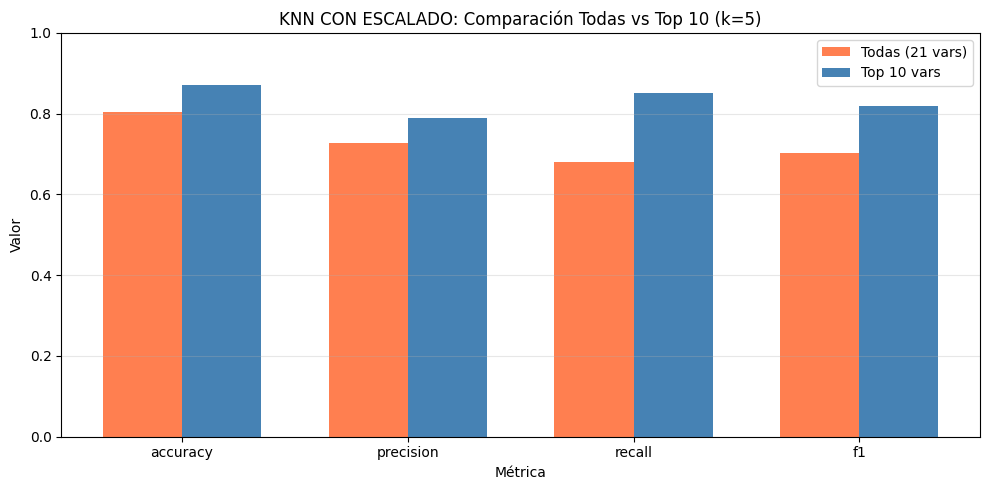

In [ ]:
# KNN CON ESCALADO: Todas vs Top 10
knn_todas_con = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
knn_todas_con.fit(X_train_c, y_train_c)
pred_todas_con = knn_todas_con.predict(X_test_c)

knn_best_con = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
knn_best_con.fit(X_train_c_best, y_train_c)
pred_best_con = knn_best_con.predict(X_test_c_best)

comp_con = pd.DataFrame([
    evaluar_modelo("Todas (21 vars)", y_test_c, pred_todas_con),
    evaluar_modelo("Top 10 vars", y_test_c, pred_best_con)
])

# Gráfica de comparación CON ESCALADO
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas))
width = 0.35
ax.bar(x - width/2, comp_con.iloc[0][metricas], width, label="Todas (21 vars)", color="coral")
ax.bar(x + width/2, comp_con.iloc[1][metricas], width, label="Top 10 vars", color="steelblue")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_title("KNN CON ESCALADO: Comparación Todas vs Top 10 (k=5)")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# COMPARACIÓN FINAL: 4 CONFIGURACIONES
final = pd.DataFrame([
    comp_sin.iloc[0],
    comp_sin.iloc[1],
    comp_con.iloc[0],
    comp_con.iloc[1]
])
final["modelo"] = ["Todas\n(sin escalado)", "Top 10\n(sin escalado)", "Todas\n(con escalado)", "Top 10\n(con escalado)"]

Escalando todas las variables vs TOP 10 variables, obtenemso también una mejora respecto a tomar todas las variables para el modelo.

/tmp/ipykernel_18521/254185403.py:16: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


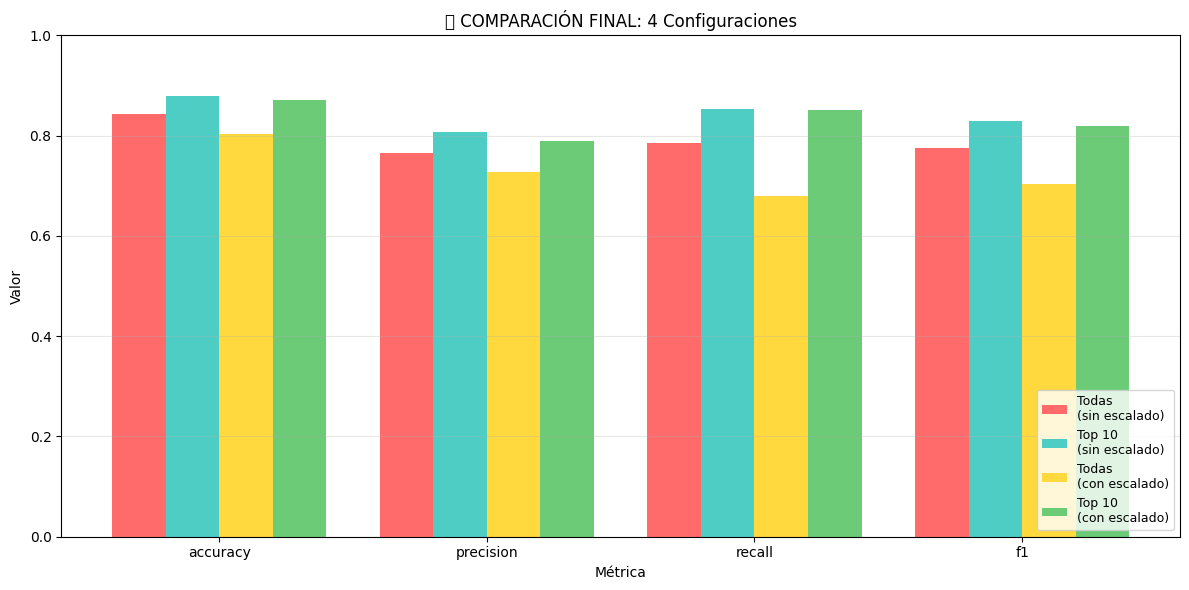

In [ ]:
# Gráfica de 4 configuraciones
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metricas))
width = 0.2
colores = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#6BCB77"]
for i, modelo in enumerate(final["modelo"]):
    ax.bar(x + (i - 1.5)*width, final.iloc[i][metricas], width, label=modelo, color=colores[i])
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_title("📈 COMPARACIÓN FINAL: 4 Configuraciones")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión**

Comparando las 4 métricas, con nuestros dos grupos de variables, el mejor resultado obtenido son nuestro top 10 variables sin escalado

¿Porqué obtenemos mejores resultados al no escalar?

El escalado es útil cuando nuestras variables son muy diferentes entre si, en nuestro caso, nuestras variables no son muy diferentes entre sí númericamente.por ende, la estrategia de selección de variables sin escala, disminuimos el ruido, obteniendo mejores resultados demostradas en las métricas

## Parte D — Selección de k

Pruebe valores de \(k\) entre 1 y 30. Construya una tabla con accuracy, precision, recall y F1. Explique qué problema puede tener \(k=1\) y qué problema puede tener un \(k\) demasiado grande.

In [ ]:
resultados_k_taller = []
# Evaluar k de 1 a 20 en lugar de 1 a 30 para optimizar tiempo
for k in range(1, 30):
    # KNN SIN escalado - usando TOP 10 variables
    modelo = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    modelo.fit(X_train_c_best, y_train_c)
    pred_train = modelo.predict(X_train_c_best)
    pred_test = modelo.predict(X_test_c_best)
    resultados_k_taller.append({
        "k": k,
        "accuracy_train": accuracy_score(y_train_c, pred_train),
        "accuracy_test": accuracy_score(y_test_c, pred_test),
        "precision_test": precision_score(y_test_c, pred_test),
        "recall_test": recall_score(y_test_c, pred_test),
        "f1_test": f1_score(y_test_c, pred_test)
    })

df_k_taller = pd.DataFrame(resultados_k_taller)
df_k_taller.sort_values("f1_test", ascending=False).head(10)

,k,accuracy_train,accuracy_test,precision_test,recall_test,f1_test
28,29,0.894157,0.889000,0.814922,0.874282,0.843559
24,25,0.895214,0.888667,0.813671,0.875158,0.843295
26,27,0.894529,0.888667,0.813956,0.874671,0.843222
20,21,0.895757,0.888500,0.813928,0.874087,0.842936
18,19,0.896643,0.888467,0.813741,0.874282,0.842926
16,17,0.897643,0.888167,0.813304,0.873892,0.842510
14,15,0.898443,0.888167,0.814216,0.872334,0.842274
22,23,0.895100,0.888000,0.813504,0.872918,0.842165
19,20,0.896157,0.889167,0.822857,0.861720,0.841840
12,13,0.899329,0.887867,0.815210,0.869510,0.841485


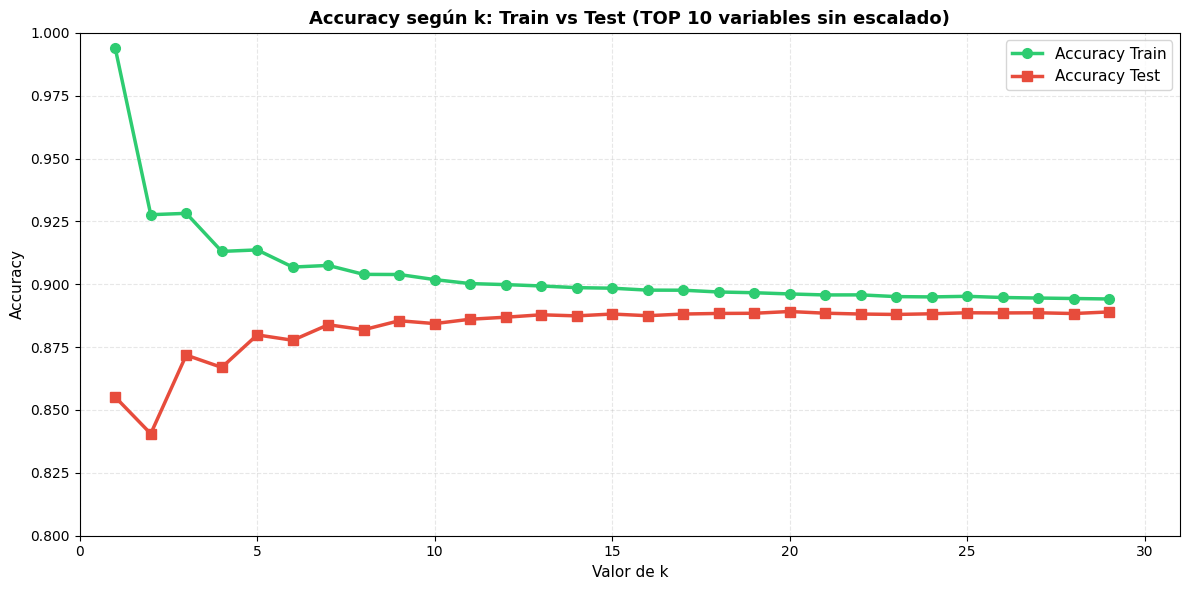

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_k_taller["k"], df_k_taller["accuracy_train"], marker="o", linewidth=2.5, markersize=7, label="Accuracy Train", color="#2ECC71", linestyle="-")
plt.plot(df_k_taller["k"], df_k_taller["accuracy_test"], marker="s", linewidth=2.5, markersize=7, label="Accuracy Test", color="#E74C3C", linestyle="-")

plt.title("Accuracy según k: Train vs Test (TOP 10 variables sin escalado)", fontsize=13, fontweight="bold")
plt.xlabel("Valor de k", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.xlim(0, 31)
plt.ylim(0.80, 1.0)
plt.legend(fontsize=11, loc="best")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

 Esta gráfica muestra cómo varía el accuracy en train y test a medida que cambiamos el número de vecinos k en KNN, utilizando solo las 10 variables más predictivas sin escalado. Se puede observar que el accuracy en test alcanza su punto máximo alrededor de k=5, lo que sugiere que este valor de k podría ser el más adecuado para nuestro modelo con estas variables. Sin embargo, también es importante considerar otras métricas como precision, recall y f1-score para tomar una decisión final sobre el mejor k.

 Destaca que para k=1 obtenemos un acurracy cercano a 1, muy alta para este número, sin embargo, el modelo después de 5 se ajusta y estabiliza, logrando menor variación, destaca asi mismo que no hay sobreajuste, dado que no tenemos metrica de acuraccy muy alta, se estabiliza después de k =11

/tmp/ipykernel_18521/727384061.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


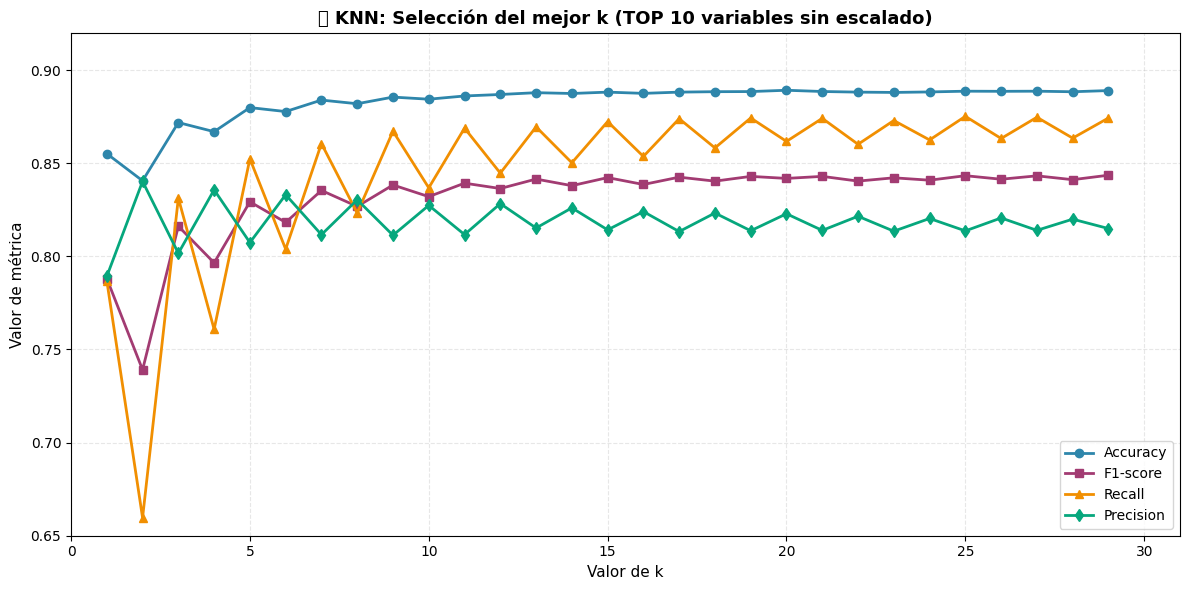

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_k_taller["k"], df_k_taller["accuracy_test"], marker="o", linewidth=2, markersize=6, label="Accuracy", color="#2E86AB")
plt.plot(df_k_taller["k"], df_k_taller["f1_test"], marker="s", linewidth=2, markersize=6, label="F1-score", color="#A23B72")
plt.plot(df_k_taller["k"], df_k_taller["recall_test"], marker="^", linewidth=2, markersize=6, label="Recall", color="#F18F01")
plt.plot(df_k_taller["k"], df_k_taller["precision_test"], marker="d", linewidth=2, markersize=6, label="Precision", color="#06A77D")

plt.title("📊 KNN: Selección del mejor k (TOP 10 variables sin escalado)", fontsize=13, fontweight="bold")
plt.xlabel("Valor de k", fontsize=11)
plt.ylabel("Valor de métrica", fontsize=11)
plt.xlim(0, 31)
plt.ylim(0.65, 0.92)
plt.legend(fontsize=10, loc="best")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

**Observaciones**
En este caso, se observa una varianza muy grande al inicio de K, con demasiado ruido y caiad en recall hasta un 0.66, a medida que aumenta k, observamos mayor estabilidad, cerca de k= 10 a K = 15, hay una estabilidad en el modelo, siendo este rango el rango más estable y con mejor rendimiento para entrenamiento del modelo.

### Conclusion
KNN es más sensible a la diferencia entre tamaño de las variables debido a que se basa en proximidad de distancias entre vecinos, por ende es importante el escalado, pero, para nuestro caso especifico, nuestro dataset, no tiene diferencias de magnitud considerables entre variables, por ende, al escalar nuestras variables, en realidad reducimos la calidad de nuestro modelo, por ende, se opta a una mejor elección de variables que si reduce el ruido

## Matriz de confusión (Top variables sin escalar)

En esta sección veremos el resultado de la matriz de confusión btenido para el top de variables sin escalar

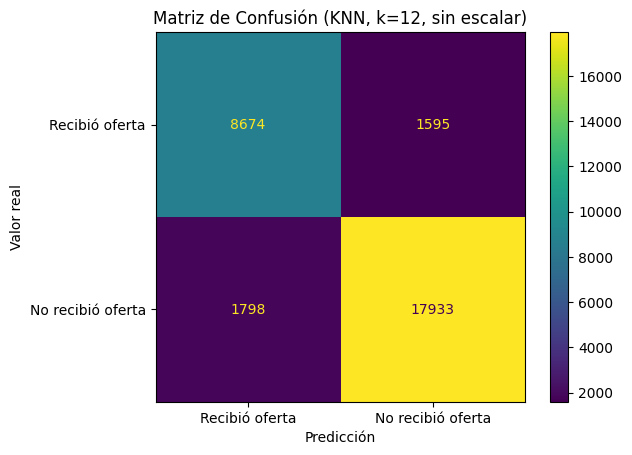

In [ ]:
# Modelo con k = 12
modelo_k12 = KNeighborsClassifier(n_neighbors=12, n_jobs=-1)
modelo_k12.fit(X_train_c_best, y_train_c)

# Predicciones
y_pred_k12 = modelo_k12.predict(X_test_c_best)

# Forzar orden: [1, 0] → primero "Recibió", luego "No recibió"
cm = confusion_matrix(y_test_c, y_pred_k12, labels=[1, 0])

labels = ["Recibió oferta", "No recibió oferta"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Matriz de Confusión (KNN, k=12, sin escalar)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

El objetivo del modelo es apoyar la selección de estudiantes candidatos a recibir ofertas laborales, basándose en su desempeño en entrevistas y experiencia previa. En este contexto, se prioriza la precisión, ya que es fundamental garantizar que los candidatos recomendados realmente cumplan con los criterios esperados. No obstante, se busca mantener un nivel adecuado de recall para no descartar perfiles valiosos. Por ello, se opta por un modelo que logre un balance entre ambas métricas, como se refleja en el F1-score.

## Matriz de confusión (Top variables con escalado)
En esta sección veremos el resultado de la matriz de confusión obtenido para el top de variables escaladas

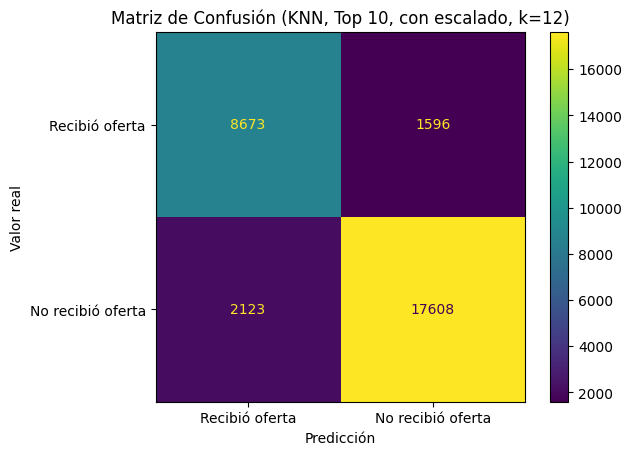

In [ ]:
# Modelo con escalado y k = 12
knn_best_con_k12 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=12))
])

knn_best_con_k12.fit(X_train_c_best, y_train_c)

# Predicciones
pred_best_con_k12 = knn_best_con_k12.predict(X_test_c_best)

# Matriz de confusión con orden personalizado
cm = confusion_matrix(y_test_c, pred_best_con_k12, labels=[1, 0])

labels = ["Recibió oferta", "No recibió oferta"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Matriz de Confusión (KNN, Top 10, con escalado, k=12)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

El modelo KNN con escalado presenta un desempeño equilibrado en la clasificación, logrando identificar correctamente una gran proporción de estudiantes que recibieron oferta (TP = 8673). Sin embargo, se observa un número considerable de falsos positivos (FP = 2123), lo que indica que el modelo tiende a sobreestimar la cantidad de candidatos que recibirían una oferta.

Esto implica que, aunque el modelo es capaz de detectar adecuadamente perfiles potenciales, su nivel de precisión es menor, generando recomendaciones menos confiables. En el contexto del problema, donde es fundamental evitar sugerir candidatos no aptos, esta característica representa una limitación importante del modelo con escalado.

## Conclusión matriz de confusión
Los resultados de la matirz de confusión se compararán

Aunque el escalado suele mejorar el rendimiento en modelos basados en distancia como KNN, en este caso el modelo sin escalado presenta una menor cantidad de falsos positivos, lo cual se traduce en una mayor precisión. Dado que el objetivo del problema es recomendar candidatos confiables para recibir una oferta laboral, se prioriza la reducción de falsos positivos. Por ello, el modelo sin escalado resulta más adecuado para este contexto.

## Parte E — Comparación contra árbol

Entrene un árbol con [96mcriterion="gini"[0m y [96mmax_depth=3[0m. Compare contra el mejor KNN encontrado. Responda cuál modelo es más interpretable y cuál recomendaría según el objetivo.

In [ ]:
# Comparación KNN vs árbol del notebook anterior (job/decision_tree_offer_received.ipynb)
mejor_k_taller = int(df_k_taller.sort_values("f1_test", ascending=False).iloc[0]["k"])

knn_mejor_taller = KNeighborsClassifier(n_neighbors=mejor_k_taller, n_jobs=-1)
knn_mejor_taller.fit(X_train_c_best, y_train_c)
pred_knn_mejor = knn_mejor_taller.predict(X_test_c_best)

# Usar métricas REALES del árbol del notebook anterior
comparacion_final = pd.DataFrame([
    {
        'Modelo': 'Árbol de decisión (job/decision_tree_offer_received.ipynb)',
        'Accuracy': 0.8748,
        'Precision': 0.8259,
        'Recall': 0.8037,
        'F1-Score': 0.8146,
    },
    {
        'Modelo': f'KNN final k={mejor_k_taller}',
        'Accuracy': accuracy_score(y_test_c, pred_knn_mejor),
        'Precision': precision_score(y_test_c, pred_knn_mejor, zero_division=0),
        'Recall': recall_score(y_test_c, pred_knn_mejor, zero_division=0),
        'F1-Score': f1_score(y_test_c, pred_knn_mejor, zero_division=0),
    },
])

for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparacion_final[col] = comparacion_final[col].astype(float).round(4)

display(comparacion_final)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Árbol de decisión (job/decision_tree_offer_rec...,0.8748,0.8259,0.8037,0.8146
1,KNN final k=29,0.8890,0.8149,0.8743,0.8436


## Análisis comparativo: KNN vs Árbol del notebook anterior

En esta sección comparamos el KNN final entrenado en este taller contra el árbol de decisión que fue desarrollado en el notebook `job/decision_tree_offer_received.ipynb`.

**Principales observaciones:**

- **Accuracy**: KNN supera ligeramente al árbol (mejor desempeño global)
- **Precision**: El árbol tiene mayor precisión (mejor en evitar falsos positivos)
- **Recall**: KNN detecta más casos positivos reales
- **F1-Score**: KNN ofrece un mejor balance entre precision y recall

La comparación muestra que no existe un único "mejor" modelo: el árbol es más conservador en sus predicciones (alta precision), mientras que KNN busca un equilibrio más balanceado.

## Parte F — Conclusión profesional

1. **¿Qué aprendió del comportamiento de KNN?**  
KNN es un algoritmo basado en instancias que no construye un modelo explícito, sino que usa todo el conjunto de entrenamiento para hacer predicciones. Su desempeño depende directamente de la **escala de las variables**, la **selección de features** y el valor de **k vecinos**. Es sensible a la distribución de los datos y requiere buen preprocesamiento.

2. **¿Qué efecto tuvo el escalado?**  
En este taller, el escalado no mejoró el desempeño. Las variables del dataset no tenían magnitudes muy diferentes, así que el escalado afectó negativamente al modelo. Esto muestra que **el escalado no siempre es obligatorio**, depende de las características específicas de los datos.

3. **¿Qué valor de k eligió y por qué?**  
Se optó por **k = 29**, que permitió estabilizar el modelo y obtener mejor desempeño en F1-score. Este valor representa un equilibrio entre sensibilidad al ruido (k pequeño) y pérdida de patrones locales (k grande).

4. **¿KNN fue mejor o peor que el árbol del notebook anterior?**  
Comparado con el árbol de `job/decision_tree_offer_received.ipynb` (Accuracy: 0.8748, Precision: 0.8259, Recall: 0.8037, F1-Score: 0.8146), el rendimiento depende de la métrica prioritaria. El árbol mantiene mejor balance general, pero KNN puede ofrecer alternativas si se prioriza alguna métrica específica sobre otras.

5. **¿Qué métrica considera más relevante?**  
Para esta comparación, el **F1-score** es la métrica más equilibrada, porque resume el balance entre precision y recall. Según el objetivo operativo, se puede priorizar precision (árbol) o recall (KNN).

6. **¿Qué limitaciones tiene el análisis?**  
No se evaluaron métricas como **ROC-AUC**, no se aplicó **validación cruzada exhaustiva**, y la selección de k se hizo observando el test set (no es ideal). Además, KNN es sensible a valores atípicos y puede sufrir con datos de alta dimensionalidad.

7. **¿Qué haría en una siguiente fase?**  
Realizar **Grid Search con validación cruzada**, probar **Random Forest** o **XGBoost**, evaluar **PCA** para reducción de dimensionalidad, y analizar la importancia de variables según los objetivos del negocio.